
---

# 🎚️ **`Normalization & Nonlinear Data Transformation in ML for Data Science`** 📊  

### 📌 **What is Normalization & Nonlinear Data Transformation?**  
In **Machine Learning (ML)**, data often needs to be **transformed** before training models.  
- **Normalization** ensures all features have a **consistent scale**, preventing larger features from dominating.  
- **Nonlinear transformations** (e.g., log, Box-Cox, power transforms) help make data more **normally distributed** and improve model performance.  

---

## ✅ **1. Why Are Normalization & Transformations Important?**  

✔ **Prevents feature dominance:** Ensures fair contribution from all features.  
✔ **Improves model convergence:** Helps gradient-based models like **Neural Networks & Logistic Regression** train faster.  
✔ **Handles skewed data:** Reduces impact of **outliers & non-Gaussian distributions**.  
✔ **Enhances interpretability:** Some models (e.g., **Linear Regression**) perform better with **normally distributed data**.  

---

## 🔢 **2. Normalization (Feature Scaling)**  

**Normalization** scales data to a fixed range, typically **[0,1]** or **[-1,1]**.

### 📏 **2.1 Min-Max Scaling (Normalization)**  
**Formula:**  
$$
X' = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

✅ **Keeps original data distribution** intact.  
✅ **Used in Deep Learning models (e.g., Neural Networks, CNNs, RNNs).**  
❌ **Sensitive to outliers** (since it depends on min/max values).  

In [1]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Sample Data
df = pd.DataFrame({'Age': [22, 25, 47, 35, 50], 'Salary': [20000, 30000, 50000, 40000, 70000]})

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("\nMin-Max Scaled Data:\n", df_scaled)



Min-Max Scaled Data:
         Age  Salary
0  0.000000     0.0
1  0.107143     0.2
2  0.892857     0.6
3  0.464286     0.4
4  1.000000     1.0



---

### 📏 **2.2 Z-Score Standardization (Mean Normalization)**  
**Formula:**  
$$
X' = \frac{X - \mu}{\sigma}
$$

✅ Centers data around **mean = 0, std deviation = 1**.  
✅ **Not affected by outliers** as much as Min-Max Scaling.  
✅ **Useful for models assuming normality (e.g., SVM, Logistic Regression, PCA).**

In [2]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("\nStandardized Data:\n", df_standardized)



Standardized Data:
         Age    Salary
0 -1.224745 -1.278724
1 -0.958496 -0.697486
2  0.993996  0.464991
3 -0.071000 -0.116248
4  1.260245  1.627467



---

## 📉 **3. Nonlinear Data Transformations**  

Many real-world datasets are **skewed**, meaning they do not follow a **normal distribution**.  
Certain ML models (e.g., **Linear Regression, LDA, PCA**) work better with **normally distributed** data.

---

### 🔹 **3.1 Log Transformation (Reducing Skewness)**  
✅ **Useful for right-skewed data** (e.g., income, population).  
✅ Converts **multiplicative relationships** into **additive relationships**.  
❌ **Not suitable for negative or zero values**.  

In [3]:

df['Log_Salary'] = np.log(df['Salary'])

print("\nLog Transformed Data:\n", df[['Salary', 'Log_Salary']])



Log Transformed Data:
    Salary  Log_Salary
0   20000    9.903488
1   30000   10.308953
2   50000   10.819778
3   40000   10.596635
4   70000   11.156251


---

### 🔹 **3.2 Box-Cox Transformation (For Skewed Data)**  
**Formula:**  
$$
X' = \frac{X^\lambda - 1}{\lambda}
$$
- **Lambda (λ)** controls transformation strength.  
- Works only for **positive** values.  

In [4]:

from scipy.stats import boxcox

df['BoxCox_Salary'], lambda_ = boxcox(df['Salary'])
print("\nBox-Cox Lambda:", lambda_)



Box-Cox Lambda: 0.21417795351631064




💡 **Use When:**  
- Data has **skewness** and you want to make it **normally distributed**.  
- **Linear models (Regression, PCA) work better after transformation**.

---

### 🔹 **3.3 Power Transformation (Yeo-Johnson)**  
✅ Works for both **positive & negative values**.  
✅ Reduces **skewness** similar to Box-Cox.  

In [ ]:

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['PowerTransformed_Salary'] = pt.fit_transform(df[['Salary']])

print("\nPower Transformed Data:\n", df[['Salary', 'PowerTransformed_Salary']])



Power Transformed Data:
    Salary  PowerTransformed_Salary
0   20000                -1.473996
1   30000                -0.611640
2   50000                 0.587040
3   40000                 0.047257
4   70000                 1.451339



---

### 🔹 **3.4 Square Root Transformation (Mild Skew Reduction)**  
**Formula:**  
$$
X' = \sqrt{X}
$$
✅ Handles **moderate skewness**.  
❌ Not as strong as log or Box-Cox.  


In [6]:

df['Sqrt_Salary'] = np.sqrt(df['Salary'])


---

## 📊 **4. Visualizing the Effects of Transformations**  

### ✅ **Before & After Log Transformation**   

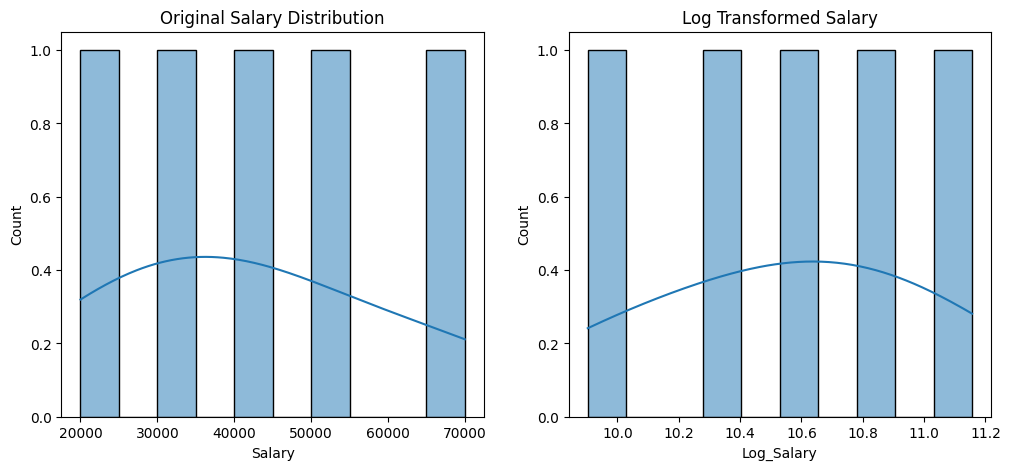

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# Plot original vs. transformed data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Salary'], bins=10, ax=axes[0], kde=True)
axes[0].set_title("Original Salary Distribution")

sns.histplot(df['Log_Salary'], bins=10, ax=axes[1], kde=True)
axes[1].set_title("Log Transformed Salary")

plt.show()



---

## 🤖 **5. Feature Scaling & Transformation in a Machine Learning Pipeline**  

### 🔍 **Using Normalization in a Pipeline (Logistic Regression Example)**

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Sample Dataset
df = pd.DataFrame({'Age': [22, 25, 47, 35, 50], 'Salary': [20000, 30000, 50000, 40000, 70000], 'Target': [0, 1, 1, 0, 1]})

# Split Data
X = df[['Age', 'Salary']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Pipeline with Scaling & Model
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Try StandardScaler, PowerTransformer, etc.
    ('classifier', RandomForestClassifier(n_estimators=100))
])

# Train Model
pipeline.fit(X_train, y_train)

# Predict & Evaluate
accuracy = pipeline.score(X_test, y_test)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.0



---

## ⚖️ **6. Choosing the Right Transformation Method**  

| **Scenario**                              | **Recommended Method** |
|--------------------------------------------|------------------------|
| Data with **different scales**              | **Min-Max Scaling**    |
| Normally distributed data                   | **Standardization (Z-score)** |
| Data with **outliers**                      | **Robust Scaling**     |
| **Right-skewed data** (e.g., Income, Population) | **Log Transformation** |
| Data with **non-negative skewness**         | **Box-Cox Transformation** |
| Data with **both positive & negative values** | **Yeo-Johnson Transformation** |
| Data with **moderate skewness**             | **Square Root Transformation** |

---

## 🏆 **7. Final Thoughts**  

✔ **Scaling & Transformation are critical for ML models**—they prevent **biased training**.  
✔ **Min-Max Scaling** is great for **Neural Networks & Deep Learning**.  
✔ **Standardization (Z-score)** works well for **PCA, SVM, Linear Models**.  
✔ **Nonlinear Transformations** (Log, Box-Cox, Yeo-Johnson) **reduce skewness** and improve model accuracy.  

💡 **Pro Tip:** Always **visualize data before & after transformation** to ensure effectiveness.  

---


## ***`Further Practice`***

In [9]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [10]:
# generate non-normal data (exponential Distribution)
np.random.seed(0)
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['values'])
df.head()


,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


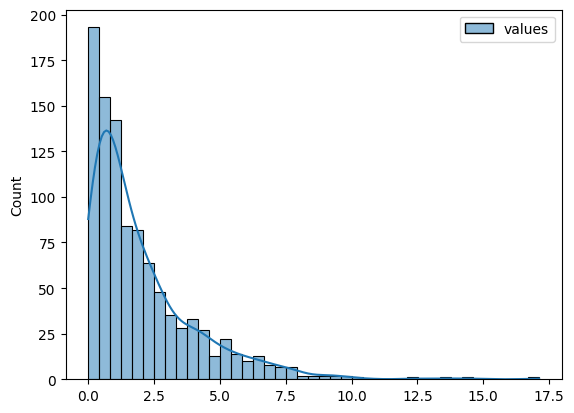

In [11]:
# create a histplot to visualize the data distribution
sns.histplot(data=df,kde=True)
plt.show()

#### **Power Transformer**

In [12]:
from sklearn.preprocessing import PowerTransformer

In [13]:
# box cox tranformer
pt_boxcox = PowerTransformer(method="box-cox")

# yeo-johnson tranformer
pt_yeo_johnson = PowerTransformer(method="yeo-johnson")

# create a new coloumn for boxcox transformed Values
df['Box Cox Transformed'] = pt_boxcox.fit_transform(df[['values']] + 1)

# create a new coloumn for yeo-johnson transformed Values
df['Yeo Jhonson Transformed'] = pt_yeo_johnson.fit_transform(df[['values']])

# view the data
df


,values,Box Cox Transformed,Yeo Jhonson Transformed
0,1.591749,0.179335,0.179335
1,2.511862,0.677331,0.677331
2,1.846446,0.339698,0.339698
3,1.574402,0.167607,0.167607
4,1.102097,-0.202107,-0.202107
...,...,...,...
995,0.205564,-1.390405,-1.390405
996,1.446892,0.077828,0.077828
997,5.574577,1.527375,1.527375
998,0.519217,-0.862872,-0.862872


#### **Quantile Transformer**

In [15]:
from sklearn.preprocessing import QuantileTransformer

In [16]:
qt_normal = QuantileTransformer(output_distribution="normal")

# create a new coloumn for yeo-johnson transformed Values
df['Quantile Transformed'] = qt_normal.fit_transform(df[['values']])

# view the data
df

,values,Box Cox Transformed,Yeo Jhonson Transformed,Quantile Transformed
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677331,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930
...,...,...,...,...
995,0.205564,-1.390405,-1.390405,-1.315958
996,1.446892,0.077828,0.077828,0.074087
997,5.574577,1.527375,1.527375,1.475269
998,0.519217,-0.862872,-0.862872,-0.748009


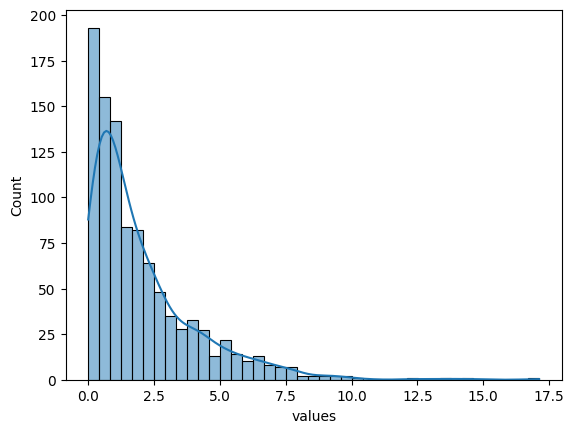

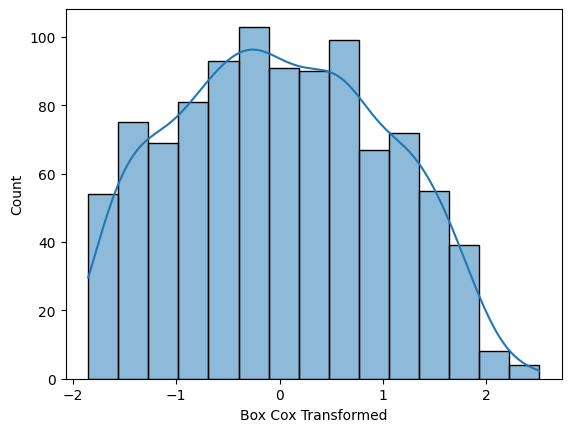

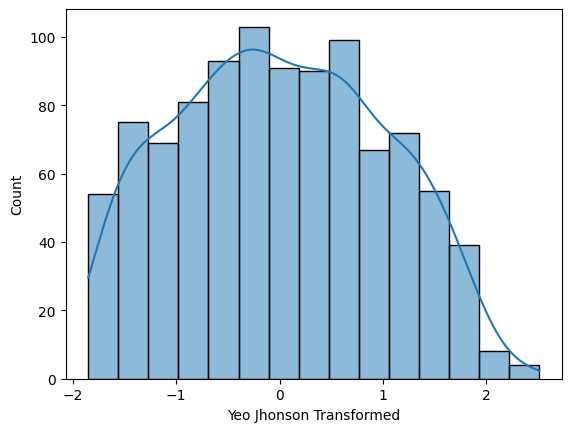

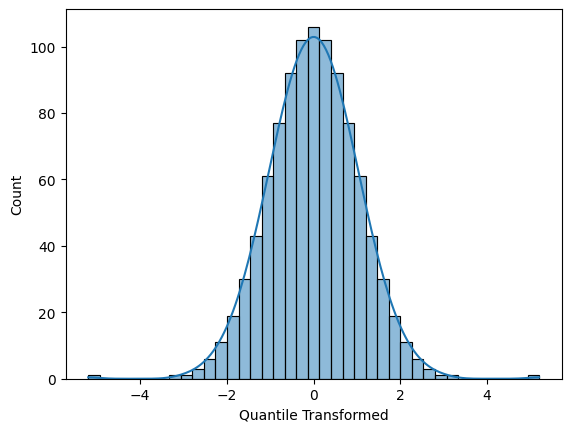

In [17]:
# creata hostograms for all columns using sns.hist and kde=true use a for loop
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()

![transformations](https://scikit-learn.org/stable/_images/sphx_glr_plot_map_data_to_normal_001.png)

---